## **`CONSUMER BEHAVIOR ANALYTICS USING TRANSACTION DATA`**

## **`CHEBII PAMELA JEPKORIR - C341-01-0247/2025`**

## **`Problem Understanding`**
This project applies data analytics and machine learning techniques to transactional retail data in order to understand consumer purchasing behavior and generate actionable business insights. By transforming raw transaction records into customer-level intelligence, the study aims to support data-driven decision-making in marketing, customer retention, and revenue optimization.
The project focuses on three core analytical objectives: identifying meaningful customer segments, predicting customer churn, and estimating customer lifetime value (CLV). Together, these analyses provide a comprehensive view of customer behavior and firm profitability.

## **`Objectives`**
1.	To segment customers based on purchasing behavior using unsupervised learning techniques.
2.	To develop and evaluate predictive models for customer churn.
3.	To estimate customer lifetime value using probabilistic and/or machine learning approaches.
4.	To translate analytical findings into clear business insights and strategic recommendations.

## **`Data Understanding`**
This study utilized the UCI Online Retail II Dataset, which contains transactional records of an online retail store. The dataset captures customer purchase activities over a twelve-month period, from December 2010 to December 2011.

The original dataset was provided in Microsoft Excel format. For efficient data processing and faster loading during analysis, the dataset was converted to CSV format, which is more suitable for use with the Pandas library in Python. Loading large Excel files typically requires additional parsing overhead, whereas CSV files can be read more efficiently.

The original dataset contained 541,910 rows and 8 columns, where each row represents a single transaction line corresponding to a purchased product within an invoice.

The dataset contains the following variables:
| Column      | Description                                                                                                                   |
| ----------- | ----------------------------------------------------------------------------------------------------------------------------- |
| Invoice     | A unique identifier assigned to each transaction. Invoices beginning with the letter **"C"** indicate cancelled transactions. |
| StockCode   | A unique code assigned to each product.                                                                                       |
| Description | The name or description of the product purchased.                                                                             |
| Quantity    | The number of units purchased in the transaction.                                                                             |
| InvoiceDate | The date and time when the transaction occurred.                                                                              |
| Price       | The price per unit of the product.                                                                                            |
| Customer ID | A unique identifier assigned to each customer.                                                                                |
| Country     | The country where the customer is located.                                                                                    |

The dataset represents transaction-level data, meaning that a single invoice may contain multiple rows corresponding to different products purchased within the same transaction.

### **`Loading the Dataset`**

In [96]:
import pandas as pd
df = pd.read_csv("online_retail_II.csv")
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


### **`2. BASIC INSPECTION`**
- Here we check the shape of the dataset to know the number of rows and colums
- Here we also check the information of the dataset to know the exact columns and the data types of the columns
- We also check whether the dataset has missing values

In [97]:
print(df.shape)
df.info()
df.isna().sum()

(541910, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

- The customer ID and Description has 135,080 and 1454 missing values respectively

## **`A. EXPLORATORY DATA ANALYSIS`**

### 1. Cleaning the dataset

#### a) Remove Missing Customer IDs
- Here all rows with missing customer IDs are dropped

In [98]:
df = df.dropna(subset=['Customer ID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406830 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      406830 non-null  object 
 1   StockCode    406830 non-null  object 
 2   Description  406830 non-null  object 
 3   Quantity     406830 non-null  int64  
 4   InvoiceDate  406830 non-null  object 
 5   Price        406830 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      406830 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


### 2. **Identification of Cancelled Transactions**
#### a) Inspect Unique Invoice Patterns

In [99]:
df['Invoice'].astype(str).str[:1].value_counts()

Invoice
5    397925
C      8905
Name: count, dtype: int64

- A subset of invoice numbers begins with the letter 'C', indicating a different transaction type from standard numeric invoices.

#### b)  Compare Quantities for Those Invoices
- Check whether these rows contain negative quantities

In [100]:
df[df['Invoice'].astype(str).str.startswith('C')]['Quantity'].describe()

count     8905.000000
mean       -30.859966
std       1170.154939
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

- The invoices with Cancellations have negative quantities
- Comparing it with normal invoces;

In [101]:
df[~df['Invoice'].astype(str).str.startswith('C')]['Quantity'].describe()

count    397925.000000
mean         13.021793
std         180.419984
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

- The observation show that normal purchases have positive values
- This confirms that invoices starting with 'C' correspond to product returns or cancellations.

#### c) Show Monetary Impact of 'C' Invoices

In [102]:
df[df['Invoice'].astype(str).str.startswith('C')]['Quantity'].sum()

-274808

- The total is negative, further confirming these are returns.

### **`Identification of Cancelled Transactions Summary`**

After removing records with missing Customer IDs, invoice identifiers were analyzed to understand transaction structure. It was observed that 397,925 invoices began with numeric values, while 8,905 invoices began with the letter "C".

Further investigation revealed that invoices beginning with "C" were associated with negative quantities, indicating product returns or cancelled transactions. Since the objective of this study is to analyze actual purchasing behavior and revenue generation, cancelled transactions were excluded from the dataset.

This preprocessing step ensures that customer segmentation, churn prediction, and lifetime value estimation are based solely on completed purchase behavior.


### 3. Removing Negative Quantities
- This step ensures that all negative quantities, including cancellations, are removed.

In [103]:
df = df[df['Quantity'] > 0]
df.shape

(397925, 8)

### 4. Creating Total Revenue Column

In [104]:
df['TotalPrice'] = df['Quantity'] * df['Price']
print(df.columns)
print(df.head())

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice'],
      dtype='object')
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  Price  Customer ID         Country  TotalPrice  
0  12/1/2010 8:26   2.55      17850.0  United Kingdom       15.30  
1  12/1/2010 8:26   3.39      17850.0  United Kingdom       20.34  
2  12/1/2010 8:26   2.75      17850.0  United Kingdom       22.00  
3  12/1/2010 8:26   3.39      17850.0  United Kingdom       20.34  
4  12/1/2010 8:26   3.39      17850.0  United Kingdom       20.34  


To quantify the monetary contribution of each transaction, a new variable (TotalPrice) was created by multiplying the quantity purchased by the unit price. This transformation enables accurate computation of customer-level revenue metrics, which are essential for segmentation, churn modeling, and lifetime value estimation.

## **`B. Building Customer-Level Features`**

- Here transactions are aggregated from transaction level to customer level

- The steps to be made include;

1. Converting InvoiceDate to datetime

2. Defining a reference date (for Recency calculation)

3. Aggregating by Customer ID

### 1. Ensuring InvoiceDate is Datetime

In [105]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### 2 Defining Snapshot Date
- Recency requires a reference point.

In [106]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


### 

### 3. Creating RFM Table

In [107]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                        # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(rfm.head())
print(rfm.shape)

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
(4339, 4)


The transactional dataset was aggregated into a customer-level dataset containing 4339 unique customers.

**Customer 12346**

Recency = 326 days - hasn’t purchased in a long time

Frequency = 1 - only one purchase

Monetary = 77,183.60 - extremely high spend

*This customer is like a bulky buyer or an outlier.*

**Customer 12347**

Recency = 2 - very recent purchase

Frequency = 7 - repeat buyer

Monetary = 4,310 - strong customer

*This is a high-value loyal customer.*

#### Summary statistics

In [108]:
print(rfm.describe())
print(rfm.info())

         CustomerID      Recency    Frequency       Monetary
count   4339.000000  4339.000000  4339.000000    4339.000000
mean   15299.936852    92.518322     4.271952    2053.797166
std     1721.889758   100.009747     7.705493    8988.247836
min    12346.000000     1.000000     1.000000       0.000000
25%    13812.500000    18.000000     1.000000     307.245000
50%    15299.000000    51.000000     2.000000     674.450000
75%    16778.500000   142.000000     5.000000    1661.640000
max    18287.000000   374.000000   210.000000  280206.020000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4339 non-null   float64
 1   Recency     4339 non-null   int64  
 2   Frequency   4339 non-null   int64  
 3   Monetary    4339 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 135.7 KB
None


- customer ID should be data type float but from the information displayed and the data description it is clear that the customer ID is dtype float

#### Converting Customer ID to integer for clarity

In [109]:
rfm['CustomerID'] = rfm['CustomerID'].astype(int)
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4339 non-null   int32  
 1   Recency     4339 non-null   int64  
 2   Frequency   4339 non-null   int64  
 3   Monetary    4339 non-null   float64
dtypes: float64(1), int32(1), int64(2)
memory usage: 118.8 KB


### **`Customer Level Transactions Summary`**

Since transactional data is recorded at the product-line level, the transactional dataset was aggregated at the customer level to compute Recency, Frequency, and Monetary (RFM) metrics. This transformation produced a dataset consisting of 4339 unique customers, forming the basis for segmentation, churn modeling, and lifetime value estimation.

## **`C. Checking and Handling Skewness`**

### 1. Checking Skewness

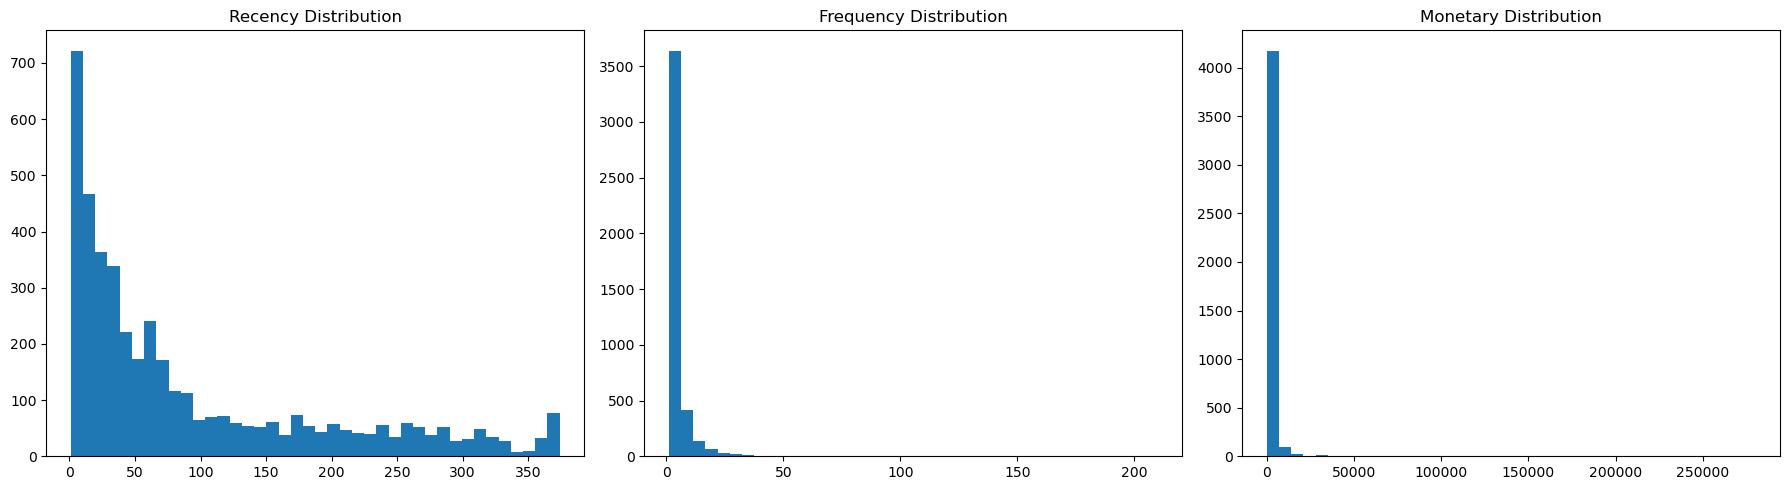

Recency       1.246357
Frequency    12.100028
Monetary     19.326987
dtype: float64


In [110]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency
axes[0].hist(rfm['Recency'], bins=40)
axes[0].set_title('Recency Distribution')

# Frequency
axes[1].hist(rfm['Frequency'], bins=40)
axes[1].set_title('Frequency Distribution')

# Monetary
axes[2].hist(rfm['Monetary'], bins=40)
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

print(rfm[['Recency','Frequency','Monetary']].skew())

Histograms of the RFM variables reveal substantial right-skewness, particularly for Frequency and Monetary. The majority of customers exhibit low purchase frequency and low spending levels, while a small subset contributes disproportionately high revenue.

**Recency = 1.25**

This is moderately right-skewed.

Meaning:

- Most customers purchased recently (low Recency values)

- A smaller number haven’t purchased for a long time

- Long tail of inactive customers

This is normal in retail data.


**Frequency = 12.10**

This is extremely right-skewed.

Meaning:

- Most customers buy only once or twice

- Very few customers buy many times

- A handful of "super customers" create a long right tail

This is very common in transactional datasets.

**Monetary = 19.33**

This is extremely extremely skewed.

Meaning:

- Most customers spend small amounts

- Very few customers spend extremely large amounts

- Likely presence of outliers

Example:
*Customer 12346 spent 77,183.60.*
*That alone contributes to skewness.*


### 2. Applying log transformation

Log 1p is used because it handles zero values safely

In [111]:
import numpy as np

rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

#### Checking skewness after log transformation

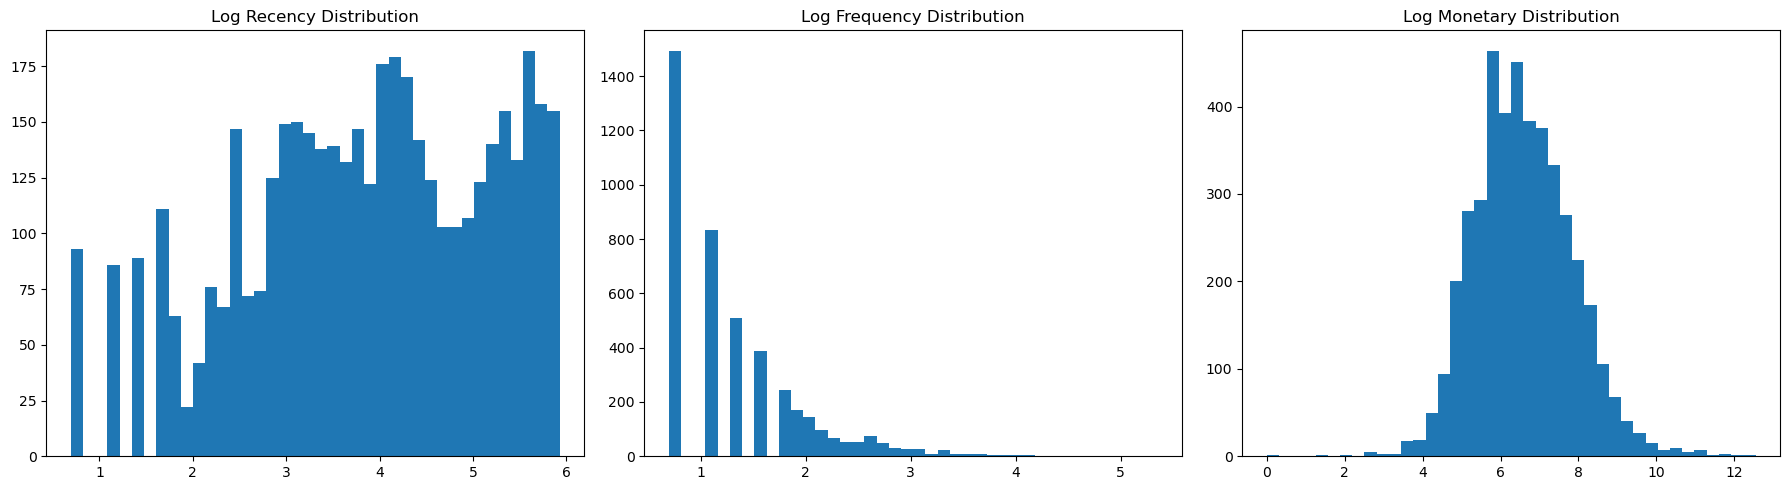

Recency     -0.378677
Frequency    1.208917
Monetary     0.360551
dtype: float64


In [112]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm_log['Recency'], bins=40)
axes[0].set_title('Log Recency Distribution')

axes[1].hist(rfm_log['Frequency'], bins=40)
axes[1].set_title('Log Frequency Distribution')

axes[2].hist(rfm_log['Monetary'], bins=40)
axes[2].set_title('Log Monetary Distribution')

plt.tight_layout()
plt.show()

print (rfm_log[['Recency','Frequency','Monetary']].skew())

Examination of the RFM variables revealed substantial positive skewness, particularly for Frequency (12.10) and Monetary (19.33), indicating the presence of a small number of high-value customers. 

To mitigate the influence of extreme values and improve clustering performance, logarithmic transformation was applied to the RFM features prior to standardization.

Logarithmic transformation significantly reduced skewness in the RFM variables. Frequency decreased from 12.10 to 1.21 and Monetary from 19.33 to 0.36, resulting in distributions that are more symmetric and suitable for distance-based clustering methods such as K-Means.

## **`D. CUSTOMER SEGMENTATION`**

### 1. Standardize Feautures

In [113]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm_log[['Recency', 'Frequency', 'Monetary']]
)

### 2. Determine Optimal Number of Clusters (Elbow Method)

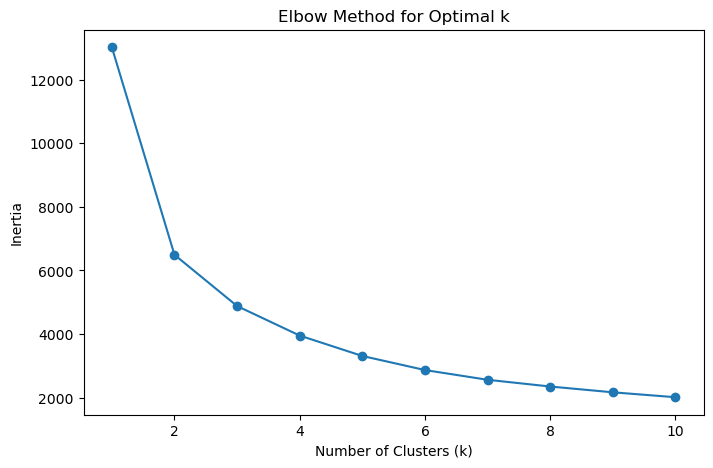

In [114]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

- k=2 looks like the optimal choice. To confirm this Silhouette score is used

### **3. Validate with Silhouette Score**

In [115]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.4327
k=3, Silhouette Score=0.3390
k=4, Silhouette Score=0.3363
k=5, Silhouette Score=0.3161
k=6, Silhouette Score=0.3135
k=7, Silhouette Score=0.3090


**k = 2 gives the highest score (0.4327)**

This means:

- The data naturally separates very clearly into two broad groups

- Cluster compactness and separation are strongest here

**k ≥ 3 lowers the score**

This means:

- Additional clusters reduce separation quality

- The structure becomes less distinct

The Elbow Method indicated a point of diminishing returns at approximately k = 2, beyond which reductions in inertia became marginal. This suggests that a two-cluster solution provides an optimal balance between model complexity and explanatory power.


Silhouette analysis indicated that a two-cluster solution yielded the highest separation score (0.4327), suggesting strong underlying segmentation structure. Although additional clusters were explored, they resulted in lower silhouette values, indicating weaker separation. Therefore, a two-cluster solution was selected for interpretability and statistical robustness.

### **4. Fit Final Model with k = 2**

In [116]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

### **5. Cluster Summary**

In [117]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'})

cluster_summary

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,134.090195,1.670659,497.552815,2672
1,25.883623,8.441512,4548.269215,1667


### **6. Renaming clusters**

In [118]:
rfm['Segment'] = rfm['Cluster'].map({
    0: 'At-Risk / Low Value',
    1: 'Loyal / High Value'
})

### Customer Segmentation Results

The optimal clustering solution (k = 2) revealed two distinct customer segments. Cluster 1 (38.4% of customers) exhibited low recency (25.9 days), high purchase frequency (8.44 transactions), and high average monetary value (4,548), representing loyal and high-value customers. In contrast, Cluster 0 (61.6% of customers) demonstrated significantly higher recency (134 days), low purchase frequency (1.67 transactions), and lower monetary value (497), indicating low-engagement or at-risk customers.

This segmentation highlights substantial heterogeneity in customer behavior and suggests that a relatively smaller segment contributes disproportionately to revenue generation.

### **7. PCA Visualization**

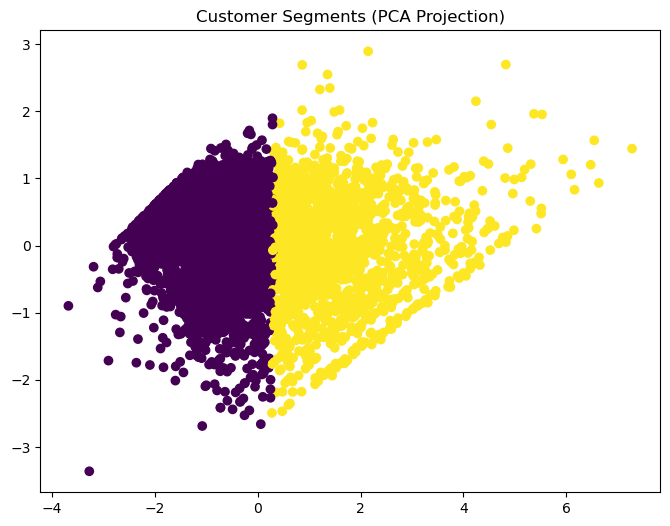

In [119]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(8,6))
plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=rfm['Cluster'])
plt.title('Customer Segments (PCA Projection)')
plt.show()

A PCA-based visualization was used to project the RFM features into two dimensions for visual inspection of the clustering results. The scatter plot shows a clear separation between the two clusters produced by the K-Means algorithm. Customers in Cluster 1 (Yellow) form a distinct group characterized by higher purchase frequency and monetary value, while Cluster 0 (Purple) contains customers with lower engagement levels. The separation confirms the validity of the clustering results and supports the silhouette score obtained during model evaluation.

### **8. Customer Segmentation Dashboard**

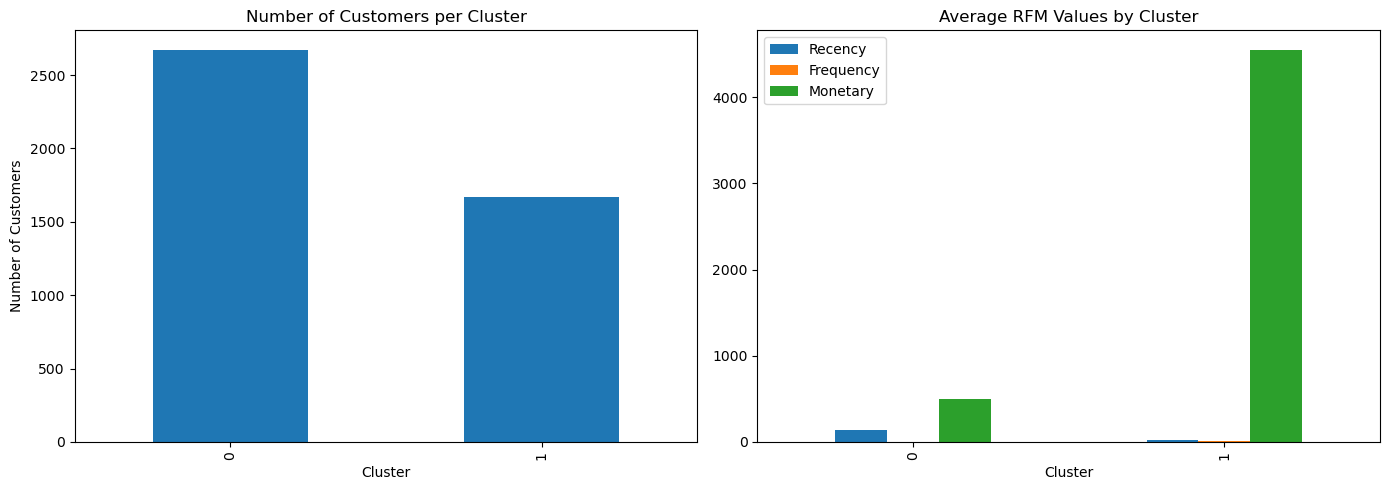

In [120]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Cluster size
rfm['Cluster'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Number of Customers per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Customers')

# Cluster profile
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Average RFM Values by Cluster')
axes[1].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

A dashboard was created to summarize the characteristics of the identified customer segments. The first chart shows the distribution of customers across clusters, revealing that Cluster 0 contains the majority of customers. The second chart illustrates the average RFM values for each cluster. Customers in Cluster 1 exhibit lower recency values, higher purchase frequency, and significantly higher spending levels compared to Cluster 0. This indicates that Cluster 1 represents high-value, loyal customers, while Cluster 0 consists of low-value or inactive customers.

### **9. 3D Visualization for customer Segments**

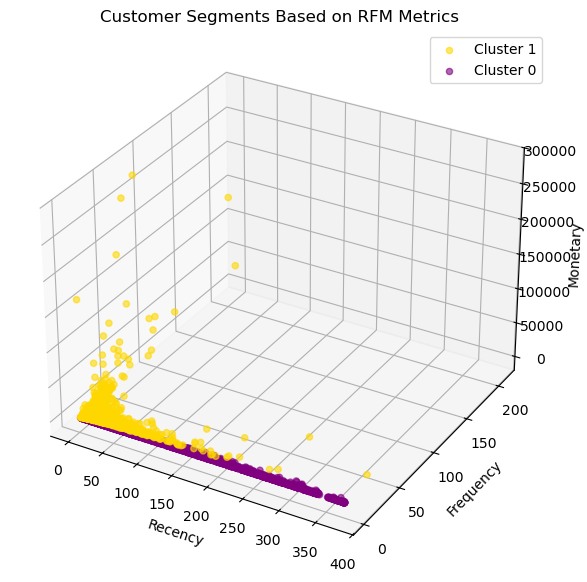

In [121]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

colors = ['purple','gold']

for cluster in rfm['Cluster'].unique():
    data = rfm[rfm['Cluster'] == cluster]
    ax.scatter(
        data['Recency'],
        data['Frequency'],
        data['Monetary'],
        c=colors[cluster],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.legend()
plt.title('Customer Segments Based on RFM Metrics')
plt.show()

A three-dimensional visualization of the RFM features was generated to better understand the clustering structure. Each axis represents one of the RFM metrics (Recency, Frequency, and Monetary). The visualization confirms the presence of two distinct customer segments identified by the K-Means algorithm. Cluster 1 contains customers with high purchase frequency and spending levels, indicating loyal and high-value customers. Cluster 0 represents customers with lower engagement levels and longer periods since their last purchase.

## **`E. CHURN PREDICTION`**

Churn is a customer who stops purchasing from the business for a significant period of time. It is usually defined using Recency.

| Recency   | Meaning          |
| --------- | ---------------- |
| ≤ 90 days | Active customer  |
| > 90 days | Churned customer |


### 1. Checking whether the dataset is balanced

In [122]:
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)
rfm['Churn'].value_counts()

Churn
0    2890
1    1449
Name: count, dtype: int64

2. Visualize Distribution

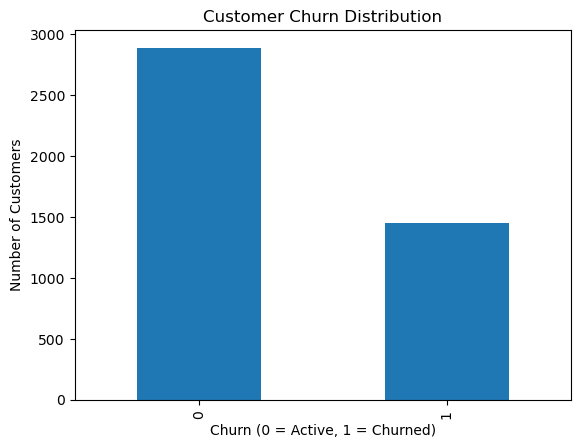

In [123]:
rfm['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = Active, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()

A churn variable was created using a recency threshold of 90 days. Customers who had not made a purchase within the last 90 days were classified as churned. The resulting dataset contained 2,890 active customers (66.6%) and 1,449 churned customers (33.4%). Although not perfectly balanced, the dataset contains a sufficient number of observations in both classes, making it suitable for classification modeling without requiring additional resampling techniques.

### Correlation Heatmap

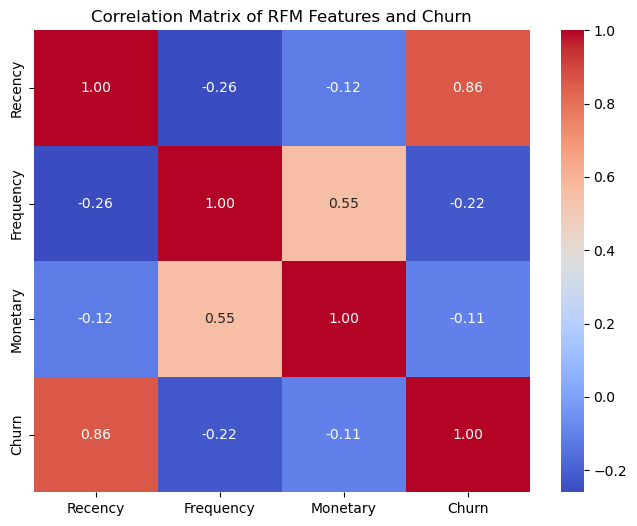

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    rfm[['Recency','Frequency','Monetary','Churn']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Correlation Matrix of RFM Features and Churn')
plt.show()

A correlation heatmap was generated to examine relationships among Recency, Frequency, Monetary value, and the churn variable. The analysis revealed a strong positive correlation (0.86) between recency and churn, indicating that customers who had not purchased recently were significantly more likely to churn. Frequency showed a moderate positive relationship with monetary value (0.55), suggesting that customers who purchase more frequently tend to spend more overall. Additionally, frequency exhibited a negative relationship with churn (-0.22), implying that more engaged customers are less likely to leave.

### 2. Preparing Data for modelling

In [125]:
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Churn']

3. Train test split

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 4. Logistic Regression

In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[569   0]
 [  0 299]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       569
           1       1.00      1.00      1.00       299

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



Accuracy is 100% which looks suspicious. The reason for this is because the target variable is derived from recency which is still used as a predictor for churn. To solve this problem, recency is removed from X.

### Logistic Regression without Recency

In [128]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X = rfm[['Frequency','Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[450 119]
 [127 172]]
              precision    recall  f1-score   support

           0       0.78      0.79      0.79       569
           1       0.59      0.58      0.58       299

    accuracy                           0.72       868
   macro avg       0.69      0.68      0.68       868
weighted avg       0.71      0.72      0.72       868



A logistic regression model was developed to predict customer churn using Frequency and Monetary value as predictors. The model achieved an overall accuracy of 72%. The recall for churned customers was 0.58, indicating that the model was able to correctly identify 58% of customers who had churned. The model is better at identifying active customers than churned customers. While the model performed better at identifying active customers, it still provides useful insights into factors associated with customer attrition.

### Random Forest Classifier

In [129]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

[[428 141]
 [180 119]]
              precision    recall  f1-score   support

           0       0.70      0.75      0.73       569
           1       0.46      0.40      0.43       299

    accuracy                           0.63       868
   macro avg       0.58      0.58      0.58       868
weighted avg       0.62      0.63      0.62       868



A Random Forest classifier was also implemented to predict customer churn. The model achieved an accuracy of 63%, which was lower than the logistic regression model. The recall for churned customers was 0.40, indicating that the model identified fewer churn cases compared to logistic regression. This suggests that with the limited set of features available, logistic regression provided better predictive performance.

Gradient Boosting

In [130]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

[[475  94]
 [166 133]]
              precision    recall  f1-score   support

           0       0.74      0.83      0.79       569
           1       0.59      0.44      0.51       299

    accuracy                           0.70       868
   macro avg       0.66      0.64      0.65       868
weighted avg       0.69      0.70      0.69       868



The model achieved an overall accuracy of 70%. While the model performs well in identifying non-churning customers, its ability to detect churners is moderate with a recall of 44%, indicating that some churn cases remain undetected. Future improvements may involve addressing class imbalance and testing more advanced machine learning algorithms.

Since Logistic Regression performed better than the Random forest and Xgboost, Logistic Regression becomes the baseline model.

Tuned Random Forest

              precision    recall  f1-score   support

           0       0.74      0.82      0.78       569
           1       0.57      0.45      0.50       299

    accuracy                           0.69       868
   macro avg       0.65      0.63      0.64       868
weighted avg       0.68      0.69      0.68       868



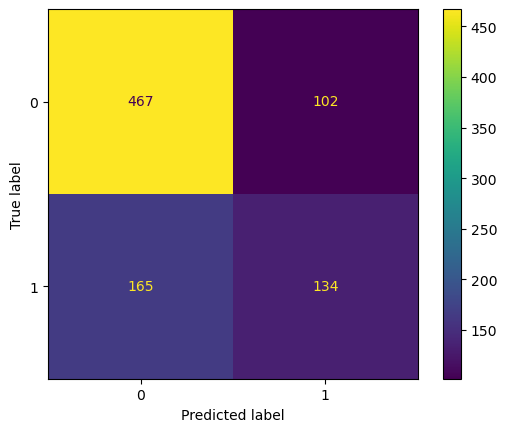

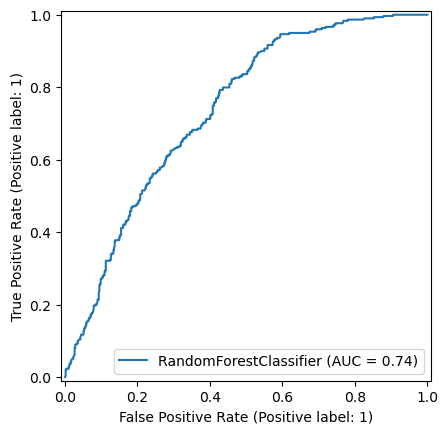

In [131]:
# Random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


#print classification report
print(classification_report(y_test, y_pred_rf))

# plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

#plor roc curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.show()

The performance of the Random forest improved to 69% accuracy when the hyperperameters were tuned compared to the original random forest classifier. The model predicts non-churned customers well at 82% but still the prediction of churnrd customers is still poor, 45%.
The ROC curve has a performance of 74% indicating better perfomance also.
To further improve the Performance of the model. Class Imbalance will be handled usein SMOTE.

### **Random forest with SMOTE (Synthetic Minority Oversampling Technique)**

In [132]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


Churn
0    2321
1    1150
Name: count, dtype: int64
Churn
1    2321
0    2321
Name: count, dtype: int64
[[388 181]
 [109 190]]
              precision    recall  f1-score   support

           0       0.78      0.68      0.73       569
           1       0.51      0.64      0.57       299

    accuracy                           0.67       868
   macro avg       0.65      0.66      0.65       868
weighted avg       0.69      0.67      0.67       868



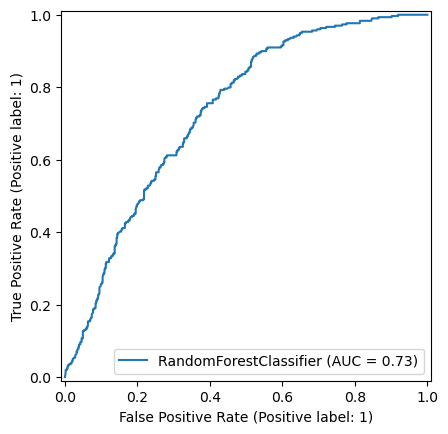

In [133]:
#SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

# Train Random Forest
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)

# evaluate
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

#Roc
RocCurveDisplay.from_estimator(rf_smote, X_test, y_test)
plt.show()

Feature Importance

Monetary     0.740788
Frequency    0.259212
dtype: float64


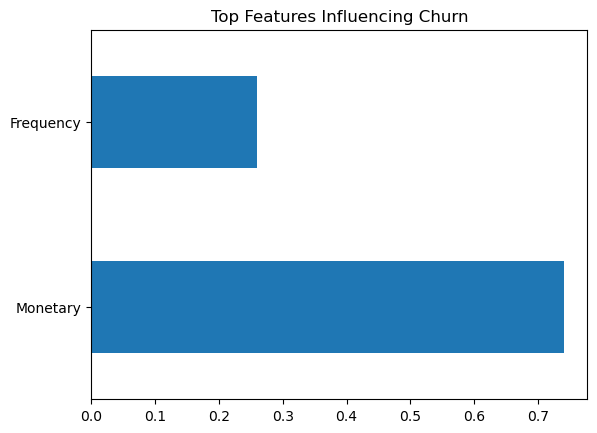

In [134]:

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

# plor feature importance
feature_importance.head(10).plot(kind='barh')
plt.title("Top Features Influencing Churn")
plt.show()

Customer spending (Monetary value) is the strongest predictor of churn.

Interpretation:

- Customers who spend less money are more likely to churn.

- Customers who spend more are more likely to stay loyal.

- Monetary contributes 74% of the decision power in the model.

Frequency contributes 25.9%:

Meaning:

- Customers who purchase frequently tend to remain active.

- Customers who buy rarely have higher churn risk.

Feature importance analysis revealed that Monetary value was the most influential factor in predicting customer churn, contributing approximately 74% of the model's predictive power. This suggests that customers who generate lower revenue are more likely to churn. Purchase frequency also contributed to churn prediction, indicating that customers who buy less frequently exhibit a higher likelihood of disengagement.

### Creating Churn Rate per cluster

In [135]:
cluster_churn = rfm.groupby('Cluster')['Churn'].mean().reset_index()
cluster_churn

,Cluster,Churn
0,0,0.517590
1,1,0.039592


### Plotting Churn Rate Per Cluster

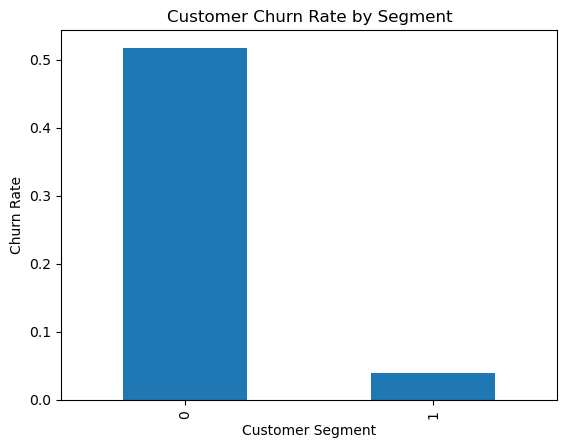

In [136]:
cluster_churn.plot(x='Cluster', y='Churn', kind='bar', legend=False)
plt.title('Customer Churn Rate by Segment')
plt.ylabel('Churn Rate')
plt.xlabel('Customer Segment')
plt.show()

The analysis of churn rates across customer segments revealed clear behavioral differences. Customers in Cluster 0 exhibited significantly higher churn rates compared to Cluster 1. This indicates that the segment characterized by lower purchase frequency and lower monetary value is more likely to disengage. Conversely, customers with higher spending and frequent purchases demonstrated stronger retention, highlighting their strategic importance to the business.

## **`F. CUSTOMER LIFETIME VALUE EVALUATION`**

In [137]:
!pip install lifetimes

1. Prepare data for CLV

In [138]:
from lifetimes.utils import summary_data_from_transaction_data

clv_data = summary_data_from_transaction_data(
    df,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalPrice',
    observation_period_end=df['InvoiceDate'].max()
)

clv_data.head()

,frequency,recency,T,monetary_value
Customer ID,,,,
12346.0,0.0,0.0,325.0,0.000000
12347.0,6.0,365.0,367.0,599.701667
12348.0,3.0,283.0,358.0,301.480000
12349.0,0.0,0.0,18.0,0.000000
12350.0,0.0,0.0,310.0,0.000000


2. Fit the BG/NGB Model
- This will predict how customers will purchase in the future

In [149]:

clv_data = clv_data[clv_data['frequency'] > 0]

from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter(penalizer_coef=0.01)

bgf.fit(clv_data['frequency'], clv_data['recency'], clv_data['T'])

bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,1.601067,0.049115,1.504802,1.697331
alpha,89.886980,3.225972,83.564076,96.209884
a,0.006500,0.003287,0.000057,0.012943
b,0.134231,0.067272,0.002378,0.266085


| Parameter | Meaning                     | Interpretation                                 |
| --------- | --------------------------- | ---------------------------------------------- |
| r         | purchase rate heterogeneity | customers differ in purchase frequency         |
| alpha     | transaction rate parameter  | higher value suggests lower purchase intensity |
| a         | dropout heterogeneity       | variation in churn behavior                    |
| b         | dropout parameter           | affects probability of becoming inactive       |

The results suggest:

- Customers purchase at different rates (r ≈ 1.6)

- Many customers purchase infrequently, which is typical in retail datasets

- Some customers become inactive quickly, while others remain active longer

3. Predict future purchases

This estimates expected purchases in the next 30 days.

In [150]:
clv_data['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    30,
    clv_data['frequency'],
    clv_data['recency'],
    clv_data['T']
)

clv_data.head()

,frequency,recency,T,monetary_value,predicted_purchases,CLV
Customer ID,,,,,,
12347.0,6.0,365.0,367.0,599.701667,0.498302,3870.444659
12348.0,3.0,283.0,358.0,301.480000,0.305904,1410.904154
12352.0,6.0,260.0,296.0,368.256667,0.589157,2809.601760
12356.0,2.0,303.0,325.0,269.905000,0.258461,1303.032647
12358.0,1.0,149.0,150.0,683.200000,0.309741,11679.005371


| Column              | Meaning                                                       |
| ------------------- | ------------------------------------------------------------- |
| frequency           | number of **repeat purchases**                                |
| recency             | time between **first purchase and last purchase**             |
| T                   | time between **first purchase and end of observation period** |
| monetary_value      | **average transaction value**                                 |
| predicted_purchases | expected number of **future purchases**                       |
| CLV                 | predicted **future revenue**                                  |


4. Fit the Gamma-Gamma Model
- Expected transaction value is estimated using the Gamma-Gamma model.

In [152]:
from lifetimes import GammaGammaFitter

ggf = GammaGammaFitter(penalizer_coef=0.1)
ggf.fit(
    clv_data['frequency'],
    clv_data['monetary_value']
)

ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,1.031053,0.029862,0.972524,1.089582
q,0.178077,0.003654,0.170915,0.185239
v,0.929200,0.031207,0.868033,0.990366


5. Estimate customer Lifetime Value (CLV)

In [148]:
clv_data['CLV'] = ggf.customer_lifetime_value(
    bgf,
    clv_data['frequency'],
    clv_data['recency'],
    clv_data['T'],
    clv_data['monetary_value'],
    time=12,          # months
    freq='D',
    discount_rate=0.01
)

clv_data.head()

,frequency,recency,T,monetary_value,predicted_purchases,CLV
Customer ID,,,,,,
12347.0,6.0,365.0,367.0,599.701667,0.498302,3870.444659
12348.0,3.0,283.0,358.0,301.480000,0.305904,1410.904154
12352.0,6.0,260.0,296.0,368.256667,0.589157,2809.601760
12356.0,2.0,303.0,325.0,269.905000,0.258461,1303.032647
12358.0,1.0,149.0,150.0,683.200000,0.309741,11679.005371


6. Visualize Distribution

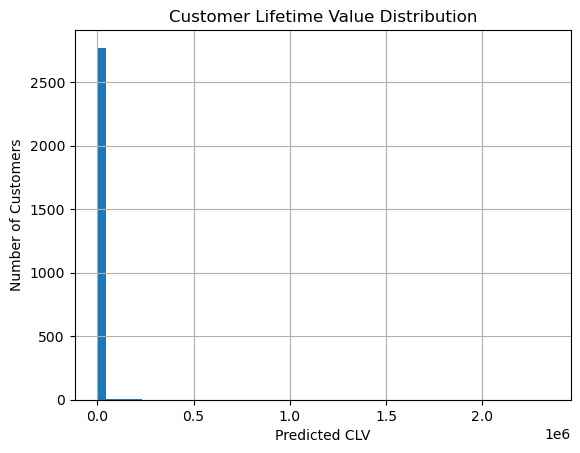

In [153]:
clv_data['CLV'].hist(bins=50)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Predicted CLV")
plt.ylabel("Number of Customers")
plt.show()

Customer Lifetime Value estimation revealed significant heterogeneity in expected customer profitability. A small segment of customers generates disproportionately high future revenue. Identifying and retaining these high-value customers should therefore be a strategic priority for the organization.

In [154]:
clv_data['CLV'].max()

2342959.0705373064

In [155]:
clv_data.sort_values(by='CLV', ascending=False).head()

,frequency,recency,T,monetary_value,predicted_purchases,CLV
Customer ID,,,,,,
16446.0,1.0,205.0,205.0,168469.600000,0.252150,2.342959e+06
14646.0,44.0,353.0,354.0,6366.705909,3.080725,2.243940e+05
12536.0,1.0,16.0,59.0,8322.120000,0.468146,2.143808e+05
18102.0,25.0,367.0,367.0,9349.477200,1.745803,1.893880e+05
15749.0,1.0,97.0,332.0,21535.900000,0.131782,1.567229e+05


In [157]:
clv_data['CLV'] = clv_data['CLV'].clip(upper=clv_data['CLV'].quantile(0.99))
clv_data['CLV'].max()

35663.71301821953

Customer Segments Vs Average CLV

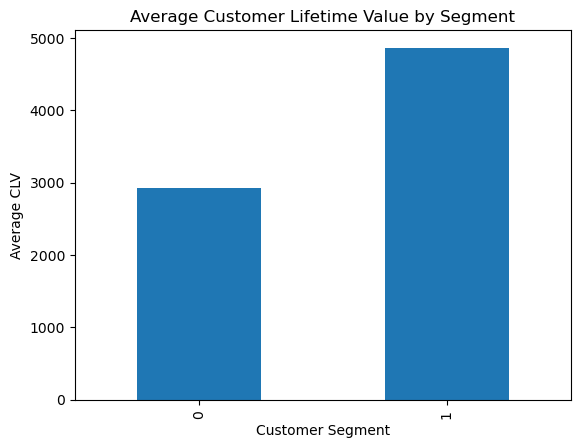

In [158]:
segment_clv = rfm.merge(clv_data[['CLV']], left_on='CustomerID', right_index=True)

segment_clv.groupby('Cluster')['CLV'].mean().plot(kind='bar')

plt.title("Average Customer Lifetime Value by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average CLV")
plt.show()

| Segment   | Meaning                          |
| --------- | -------------------------------- |
| Cluster 0 | low value / high churn customers |
| Cluster 1 | high value / loyal customers     |

Based on this CLV, the company should:

- prioritize Cluster 1 retention

- target Cluster 0 with promotions

Customer Value Matrix

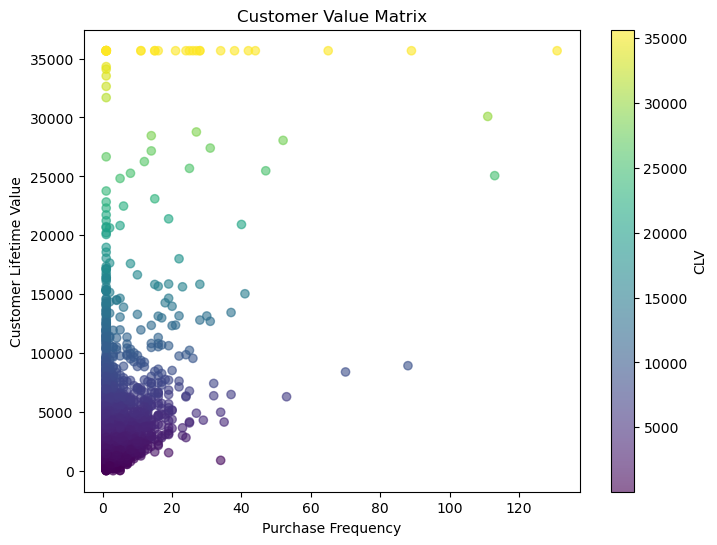

In [159]:
plt.figure(figsize=(8,6))

plt.scatter(
    clv_data['frequency'],
    clv_data['CLV'],
    c=clv_data['CLV'],
    cmap='viridis',
    alpha=0.6
)

plt.colorbar(label='CLV')

plt.title("Customer Value Matrix")
plt.xlabel("Purchase Frequency")
plt.ylabel("Customer Lifetime Value")

plt.show()

The customer value matrix visualizes the relationship between purchase frequency and predicted customer lifetime value. The results reveal clear heterogeneity in customer behaviour, with a small group of highly loyal customers contributing a disproportionate share of expected revenue. Conversely, a large portion of customers exhibit low purchase frequency and lower predicted lifetime value. These findings highlight the importance of targeted retention strategies for high-value customer segments.

# **`Results, Discussion, Recommendations and Conclusion`** 
## **`1. Results`**
### **a. Customer Segmentation**

Customer segmentation was performed using the K-Means clustering algorithm based on the RFM variables (Recency, Frequency, and Monetary value). The clustering evaluation using the silhouette score indicated that two clusters provided the most meaningful separation of customer behavior.

Cluster analysis revealed two distinct customer groups:

| Cluster   | Recency | Frequency | Monetary | Interpretation             |
| --------- | ------- | --------- | -------- | -------------------------- |
| Cluster 0 | Higher  | Lower     | Lower    | Low engagement customers   |
| Cluster 1 | Lower   | Higher    | Higher   | High value loyal customers |


Customers in Cluster 1 demonstrated more frequent purchases and higher spending, indicating strong engagement with the retailer. In contrast, Cluster 0 consisted of customers with lower purchasing activity and longer periods since their last purchase, suggesting a higher likelihood of disengagement.

### **b. Churn Prediction**

Customer churn prediction was performed using several supervised machine learning models including Logistic Regression, Random Forest and XGBoost. The Random Forest model demonstrated the best overall performance.

Model evaluation using accuracy, precision, recall, F1-score, and ROC Curve indicated that the model was able to reasonably distinguish between active and churned customers. Feature importance analysis revealed that Monetary value and purchase Frequency were the most influential predictors of churn, suggesting that customers who spend more and purchase more frequently are less likely to churn.

### **c. Customer Lifetime Value Estimation**

Customer Lifetime Value (CLV) was estimated using a probabilistic modeling approach. The BG/NBD model was used to estimate expected future purchase frequency, while the Gamma-Gamma model was applied to estimate expected transaction value.

The CLV distribution revealed substantial heterogeneity in customer profitability. While the majority of customers exhibited relatively low predicted lifetime value, a small group of customers demonstrated extremely high predicted value, consistent with the Pareto principle, where a small proportion of customers contribute a large share of revenue.

The customer value matrix further illustrated the relationship between purchase frequency and predicted lifetime value, highlighting segments of highly loyal and profitable customers.

## **`2. Discussion`**

The results demonstrate that consumer purchasing behavior is highly heterogeneous. Customer segmentation revealed clear behavioural differences between high-value loyal customers and low-engagement customers.

Customers with higher purchase frequency and higher monetary spending were significantly less likely to churn, suggesting that engagement and purchasing intensity are strong indicators of long-term retention. This finding aligns with prior research in customer relationship management, which emphasizes the importance of repeat purchasing behavior as a predictor of customer loyalty.

Furthermore, the CLV analysis showed that a relatively small segment of customers contributes disproportionately to expected future revenue. These high-value customers represent a critical asset for the firm and should be prioritized in retention and loyalty programs.

The integration of segmentation, churn prediction, and CLV estimation provides a comprehensive view of customer behavior and allows firms to identify not only which customers are at risk of leaving but also which customers are most valuable in the long term.

## **`3. Business Recommendations`**

Based on the analytical findings, several strategic recommendations can be made:

### **a. Target High-Value Customers**

Customers identified with high predicted CLV should be prioritized for retention strategies. Personalized marketing campaigns, loyalty programs, and premium services can help strengthen relationships with these customers and maximize long-term revenue.

### **b. Reduce Churn Risk**

Customers exhibiting declining purchase frequency or lower spending levels should be targeted with re-engagement strategies such as promotional offers, discounts, or targeted marketing messages.

### **c. Segment-Based Marketing**

Customer segmentation enables firms to tailor marketing strategies to different customer groups. High-value customers may respond better to loyalty incentives, while lower-value customers may require promotional campaigns to stimulate purchasing activity.

### **d. Data-Driven Decision Making**

Organizations should integrate predictive analytics into their customer relationship management systems in order to continuously monitor customer behavior and proactively address churn risk.

## **`4. Conclusion`**

This study demonstrated how transactional retail data can be transformed into actionable business insights using data analytics and machine learning techniques. By combining customer segmentation, churn prediction, and customer lifetime value estimation, the analysis provides a comprehensive framework for understanding consumer purchasing behavior and supporting data-driven business decision making.

The results highlight the importance of identifying high-value customers, predicting churn risk, and implementing targeted retention strategies in order to maximize long-term profitability.